In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [4]:
parent_llm = ChatGroq(
    model="openai/gpt-oss-120b"
)
subgraph_llm = ChatGroq(
    model="openai/gpt-oss-120b"
)

In [5]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

In [6]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [7]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [8]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

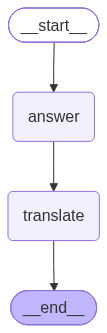

In [9]:
graph = parent_builder.compile()

graph

In [10]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': '**Quantum physics** (also called quantum mechanics or quantum theory) is the branch of physics that describes how the universe works at the smallest scales—atoms, molecules, electrons, photons, and other sub‑atomic particles. At these scales, the rules of classical physics (Newton’s laws, Maxwell’s equations, etc.) no longer give accurate predictions, and a new set of principles is needed.\n\n---\n\n## Core Ideas\n\n| Concept | What it means | Everyday analogy (if any) |\n|---------|---------------|---------------------------|\n| **Quantization** | Certain properties (energy, angular momentum, electric charge) can only take on discrete “chunks” or *quanta* rather than any continuous value. | Like climbing a staircase: you can stand on step 1, 2, 3 … but not halfway between steps. |\n| **Wave‑Particle Duality** | Particles such as electrons and photons exhibit both wave‑like and particle‑like behavior depending on how you observe t